### `0. Colab Setup `

In [3]:
import os

## Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print('Google Drive mounted successfully!')
except:
    IN_COLAB = False
    print('Not running in Google Colab.')

## Unzip the dataset from Google Drive (faster than reading directly from drive)
if IN_COLAB:
    zip_path = '/content/drive/MyDrive/brain_tumor_dataset.zip'
    if os.path.exists(zip_path):
        print('Extracting dataset...')
        !unzip -q "{zip_path}" -d /content/
        print('Dataset extracted to /content/brain_tumor_dataset')
    else:
        print(f'Error: Could not find {zip_path}. Please upload the zip file to your Google Drive.')


Mounted at /content/drive
Google Drive mounted successfully!
Extracting dataset...
Dataset extracted to /content/brain_tumor_dataset


### `1. Import the main libraries`

In [2]:
## Major Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

## Other
import cv2, warnings
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### `2. Load data and look at the big picture`

In [4]:
## Set paths
if 'IN_COLAB' in globals() and IN_COLAB:
    DATASET_DIR = '/content/brain_tumor_dataset'
else:
    DATASET_DIR = os.path.join(os.getcwd(), 'brain_tumor_dataset')

TRAIN_DIR = os.path.join(DATASET_DIR, 'Training')
TEST_DIR = os.path.join(DATASET_DIR, 'Testing')

## Configuration
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS        = 30
LEARNING_RATE = 0.0001
NUM_CLASSES   = 4
CLASS_NAMES   = sorted(os.listdir(TRAIN_DIR))
print('Classes:', CLASS_NAMES)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
## Count images per class
data_info = []
for split in ['Training', 'Testing']:
    split_dir = os.path.join(DATASET_DIR, split)
    for cls in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls)
        if os.path.isdir(cls_dir):
            count = len(os.listdir(cls_dir))
            data_info.append({'Split': split, 'Class': cls, 'Count': count})

df_info = pd.DataFrame(data_info)
df_info

,Split,Class,Count
0,Training,glioma,1400
1,Training,meningioma,1400
2,Training,notumor,1400
3,Training,pituitary,1400
4,Testing,glioma,400
5,Testing,meningioma,400
6,Testing,notumor,400
7,Testing,pituitary,400


* > The dataset has **5600 training** and **1600 testing** images
* > There are **4 classes**: glioma, meningioma, notumor, pituitary
* > The dataset is **perfectly balanced** (equal samples per class)

### `3. Exploratory Data Analysis (EDA)`

#### Class Distribution

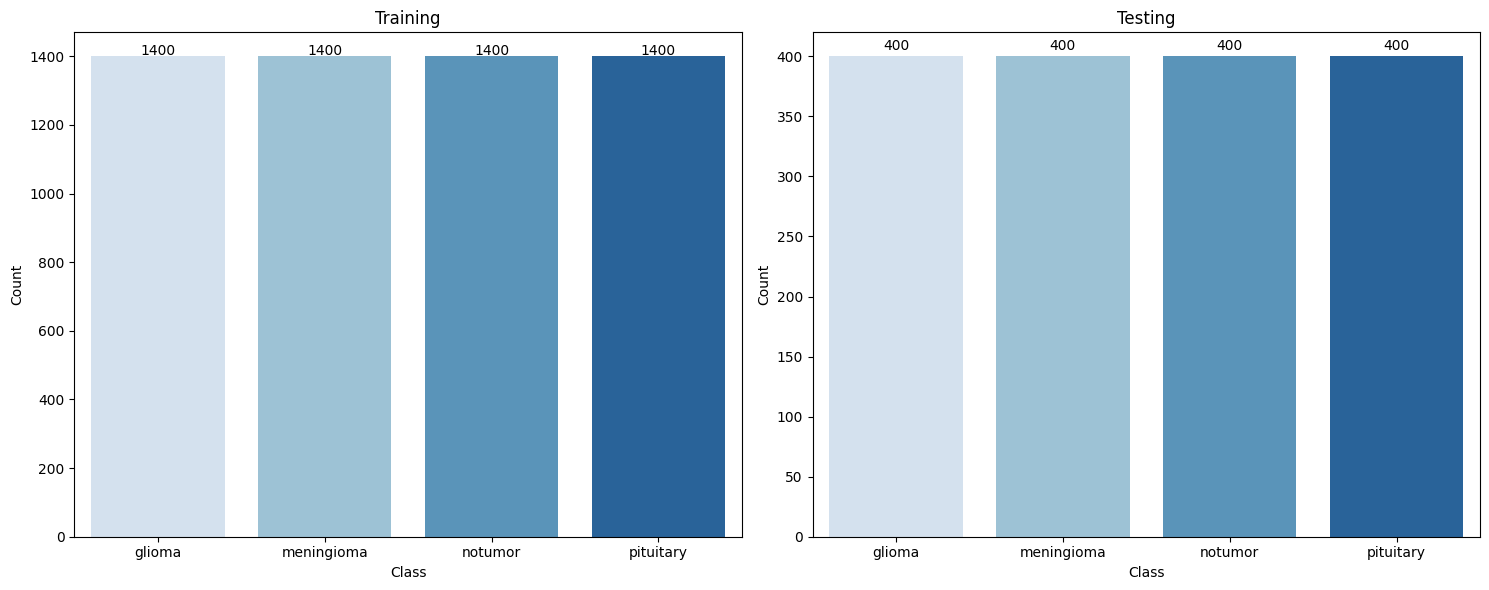

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(15,6))

for i, split in enumerate(['Training', 'Testing']):

    data = df_info[df_info['Split'] == split]

    sns.barplot(x=data['Class'], y=data['Count'], palette='Blues', errorbar=None,ax=ax[i])

    ax[i].set_title(split)

    for j, count in enumerate(data['Count']):
        ax[i].text(j, count + 5, str(count), ha='center')

plt.tight_layout()
plt.show()

#### Sample Images

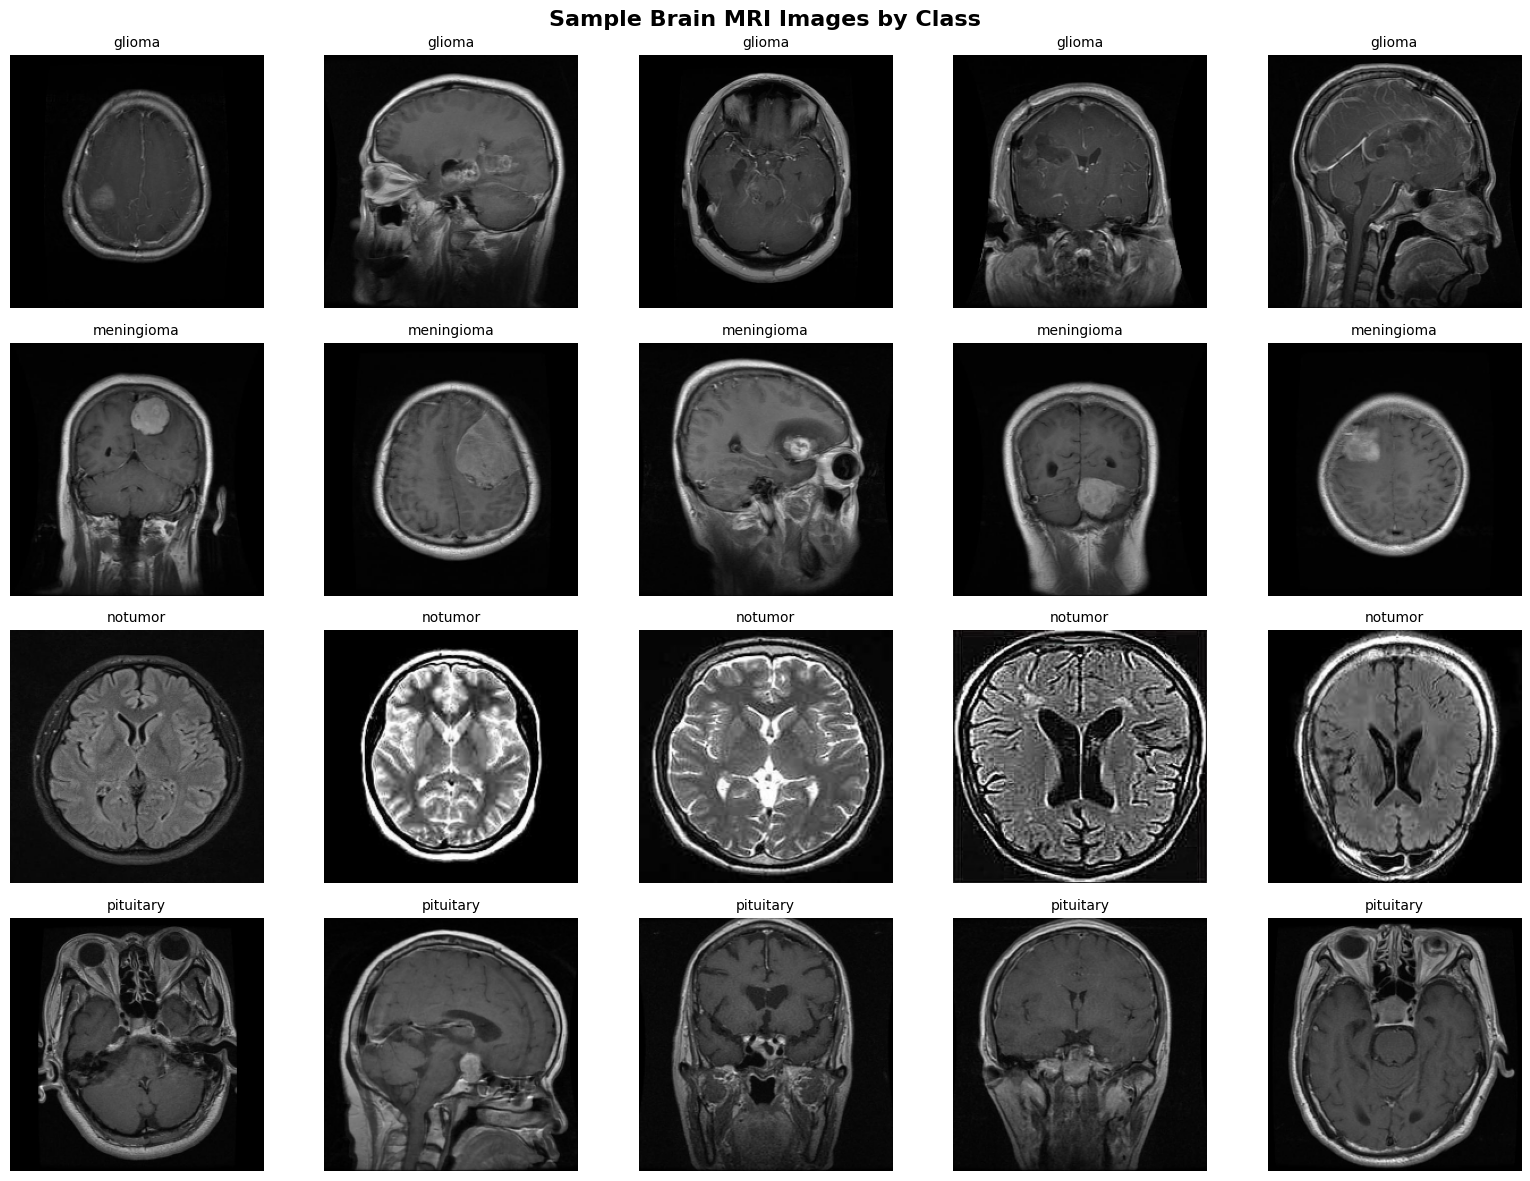

In [53]:
## Display sample images from each class
fig, axes = plt.subplots(4, 5, figsize=(16, 12))
fig.suptitle('Sample Brain MRI Images by Class', fontsize=16, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(cls_dir)[:5]
    for col, img_name in enumerate(images):
        img_path = os.path.join(cls_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        axes[row][col].imshow(img)
        axes[row][col].set_title(cls, fontsize=10)
        axes[row][col].axis('off')

plt.tight_layout()
plt.show()

#### Image Size Analysis

Width  - Min: 150, Max: 1168, Mean: 452
Height - Min: 168, Max: 1178, Mean: 456


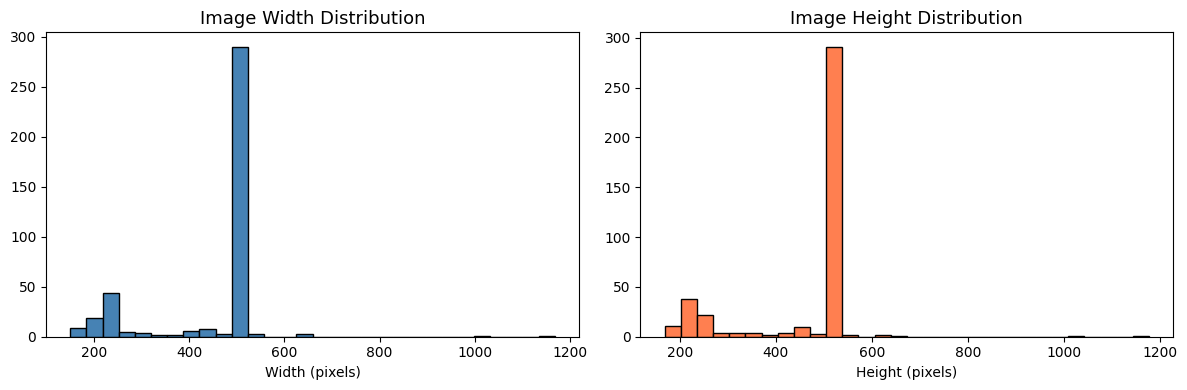

In [8]:
## Analyze image dimensions
widths, heights = [], []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(cls_dir)[:100]:  ## sample 100 per class
        img = cv2.imread(os.path.join(cls_dir, img_name))
        if img is not None:
            h, w = img.shape[:2]
            widths.append(w)
            heights.append(h)

print(f'Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}')
print(f'Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Image Width Distribution', fontsize=13)
axes[0].set_xlabel('Width (pixels)')
axes[1].hist(heights, bins=30, color='coral', edgecolor='black')
axes[1].set_title('Image Height Distribution', fontsize=13)
axes[1].set_xlabel('Height (pixels)')
plt.tight_layout()
plt.show()

### `4. Data Preprocessing & Augmentation`

In [9]:
## Training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

## Testing data - only rescaling
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

## Create generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print(f'Training samples: {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')
print(f'Test samples: {test_generator.samples}')
print(f'Class indices: {train_generator.class_indices}')

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Training samples: 4480
Validation samples: 1120
Test samples: 1600
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


#### Visualize Augmented Images

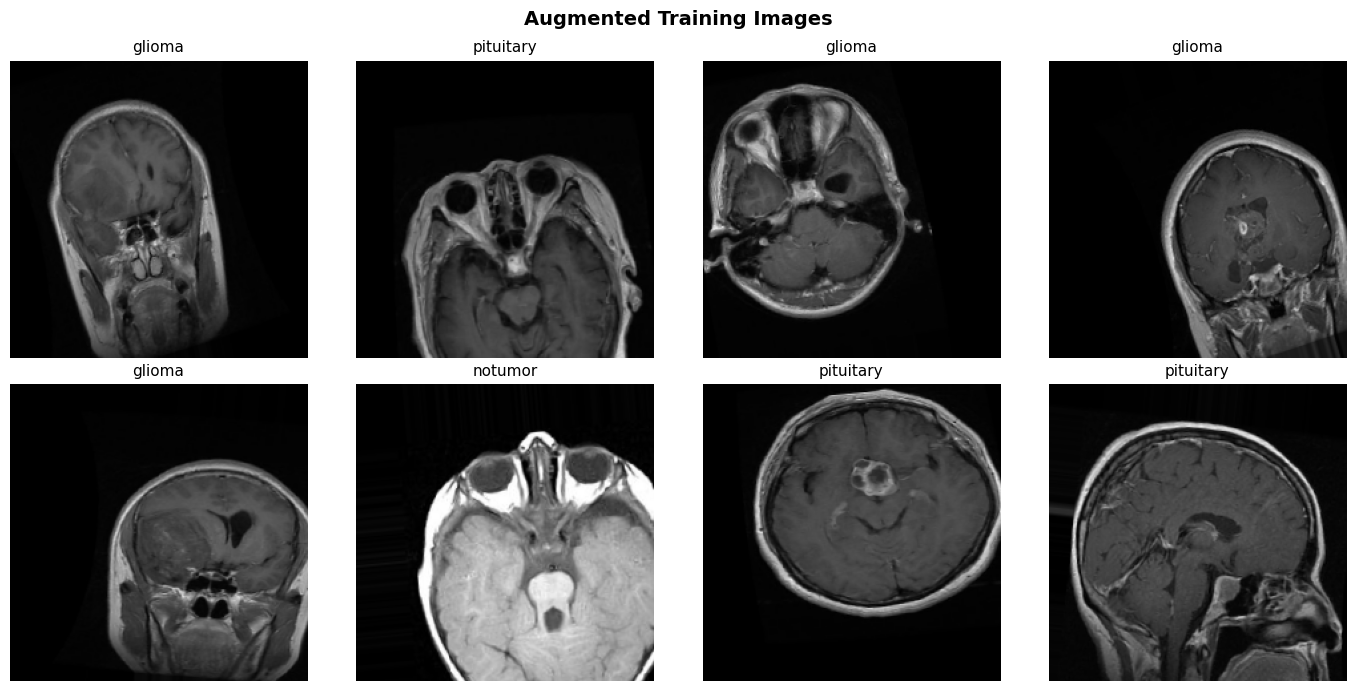

In [10]:
## Show augmented samples
images, labels = next(train_generator)
class_labels = list(train_generator.class_indices.keys())

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Augmented Training Images', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i])
        ax.set_title(class_labels[np.argmax(labels[i])], fontsize=11)
        ax.axis('off')
plt.tight_layout()
plt.show()

### `5. Build the Model (Transfer Learning - VGG16)`

In [11]:
## Load VGG16 pre-trained on ImageNet
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

## Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

## Unfreeze last 4 layers for fine-tuning
for layer in base_model.layers[-4:]:
    layer.trainable = True

## Build classification head
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

## Compile
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,112,772 (57.65 MB)

 Trainable params: 7,475,972 (28.52 MB)

 Non-trainable params: 7,636,800 (29.13 MB)

### `6. Train the Model`

In [12]:
## Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('models/brain_tumor_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

## Train
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.6218 - loss: 1.0260
Epoch 1: val_accuracy improved from None to 0.47321, saving model to models/brain_tumor_model.h5



Epoch 1: finished saving model to models/brain_tumor_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 108s 634ms/step - accuracy: 0.7165 - loss: 0.7583 - val_accuracy: 0.4732 - val_loss: 1.2227 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.8449 - loss: 0.4389
Epoch 2: val_accuracy improved from 0.47321 to 0.77768, saving model to models/brain_tumor_model.h5



Epoch 2: finished saving model to models/brain_tumor_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 86s 610ms/step - accuracy: 0.8440 - loss: 0.4367 - val_accuracy: 0.7777 - val_loss: 0.5641 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.8813 - loss: 0.3357
Epoch 3: val_accuracy did not improve from 0.77768
140/140 ━━━━━━━━━━━━━━━━━━━━ 85s 607ms/step - accuracy: 0.8808 - loss: 0.3384 - val_accuracy: 0.5705 - val_loss: 1.2973 - learning_rate: 1.0000e-04
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8932 - loss: 0.3178
Epoch 4: val_accuracy improved from 0.77768 to 0.80000, saving model to models/brain_tumor_model.h5



Epoch 4: finished saving model to models/brain_tumor_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 86s 614ms/step - accuracy: 0.8955 - loss: 0.3029 - val_accuracy: 0.8000 - val_loss: 0.5238 - learning_rate: 1.0000e-04
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9142 - loss: 0.2532
Epoch 5: val_accuracy improved from 0.80000 to 0.88482, saving model to models/brain_tumor_model.h5



Epoch 5: finished saving model to models/brain_tumor_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 85s 611ms/step - accuracy: 0.9083 - loss: 0.2591 - val_accuracy: 0.8848 - val_loss: 0.3378 - learning_rate: 1.0000e-04
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9133 - loss: 0.2490
Epoch 6: val_accuracy did not improve from 0.88482
140/140 ━━━━━━━━━━━━━━━━━━━━ 85s 606ms/step - accuracy: 0.9154 - loss: 0.2404 - val_accuracy: 0.8813 - val_loss: 0.3667 - learning_rate: 1.0000e-04
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9301 - loss: 0.2172
Epoch 7: val_accuracy did not improve from 0.88482
140/140 ━━━━━━━━━━━━━━━━━━━━ 85s 609ms/step - accuracy: 0.9281 - loss: 0.2093 - val_accuracy: 0.8830 - val_loss: 0.3723 - learning_rate: 1.0000e-04
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.9391 - loss: 0.1663
Epoch 8: val_accuracy improved from 0.88482 to 0.93750, saving model to models/brain_tumor_model.h5


...


Epoch 24: finished saving model to models/brain_tumor_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 89s 631ms/step - accuracy: 0.9922 - loss: 0.0250 - val_accuracy: 0.9723 - val_loss: 0.0954 - learning_rate: 2.5000e-05
Epoch 25/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.9888 - loss: 0.0376
Epoch 25: val_accuracy did not improve from 0.97232
140/140 ━━━━━━━━━━━━━━━━━━━━ 89s 630ms/step - accuracy: 0.9908 - loss: 0.0301 - val_accuracy: 0.9705 - val_loss: 0.0960 - learning_rate: 2.5000e-05
Epoch 26/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.9912 - loss: 0.0264
Epoch 26: val_accuracy improved from 0.97232 to 0.97321, saving model to models/brain_tumor_model.h5



Epoch 26: finished saving model to models/brain_tumor_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 88s 630ms/step - accuracy: 0.9906 - loss: 0.0272 - val_accuracy: 0.9732 - val_loss: 0.1064 - learning_rate: 2.5000e-05
Epoch 27/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.9921 - loss: 0.0260
Epoch 27: val_accuracy improved from 0.97321 to 0.97411, saving model to models/brain_tumor_model.h5



Epoch 27: finished saving model to models/brain_tumor_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 88s 627ms/step - accuracy: 0.9915 - loss: 0.0292 - val_accuracy: 0.9741 - val_loss: 0.0874 - learning_rate: 2.5000e-05
Epoch 28/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.9868 - loss: 0.0323
Epoch 28: val_accuracy did not improve from 0.97411
140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 625ms/step - accuracy: 0.9871 - loss: 0.0329 - val_accuracy: 0.9714 - val_loss: 0.1013 - learning_rate: 2.5000e-05
Epoch 29/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.9936 - loss: 0.0234
Epoch 29: val_accuracy improved from 0.97411 to 0.97500, saving model to models/brain_tumor_model.h5



Epoch 29: finished saving model to models/brain_tumor_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 625ms/step - accuracy: 0.9933 - loss: 0.0247 - val_accuracy: 0.9750 - val_loss: 0.0980 - learning_rate: 2.5000e-05
Epoch 30/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9911 - loss: 0.0242
Epoch 30: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.

Epoch 30: val_accuracy improved from 0.97500 to 0.97589, saving model to models/brain_tumor_model.h5



Epoch 30: finished saving model to models/brain_tumor_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 91s 649ms/step - accuracy: 0.9920 - loss: 0.0261 - val_accuracy: 0.9759 - val_loss: 0.0899 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 27.


In [54]:
# Phase 1 final results
phase1_train_acc = max(history.history['accuracy'])
phase1_val_acc   = max(history.history['val_accuracy'])
phase1_epochs    = len(history.history['accuracy'])

print('── Phase 1 Results ──────────────────────')
print(f'Best Train Accuracy : {phase1_train_acc:.4f}')
print(f'Best Val Accuracy   : {phase1_val_acc:.4f}')
print(f'Stopped at Epoch    : {phase1_epochs}')

# Phase 2 final results
phase2_train_acc = max(history_ft.history['accuracy'])
phase2_val_acc   = max(history_ft.history['val_accuracy'])
phase2_epochs    = len(history_ft.history['accuracy'])

print('\n── Phase 2 Fine-tuning Results ──────────')
print(f'Best Train Accuracy : {phase2_train_acc:.4f}')
print(f'Best Val Accuracy   : {phase2_val_acc:.4f}')
print(f'Stopped at Epoch    : {phase2_epochs}')

# Did fine-tuning actually help?
diff = phase2_val_acc - phase1_val_acc
print('\n── Verdict ──────────────────────────────')
if diff > 0.005:
    print(f'Fine-tuning helped! +{diff*100:.2f}% improvement ✅')
elif diff < -0.005:
    print(f'Fine-tuning hurt the model! {diff*100:.2f}% drop ❌')
else:
    print(f'No significant change ({diff*100:.2f}%) — fine-tuning not worth it 🤷')

── Phase 1 Results ──────────────────────
Best Train Accuracy : 0.9933
Best Val Accuracy   : 0.9759
Stopped at Epoch    : 30

── Phase 2 Fine-tuning Results ──────────
Best Train Accuracy : 0.9973
Best Val Accuracy   : 0.9786
Stopped at Epoch    : 13

── Verdict ──────────────────────────────
No significant change (0.27%) — fine-tuning not worth it 🤷


### `7. Training History Visualization`

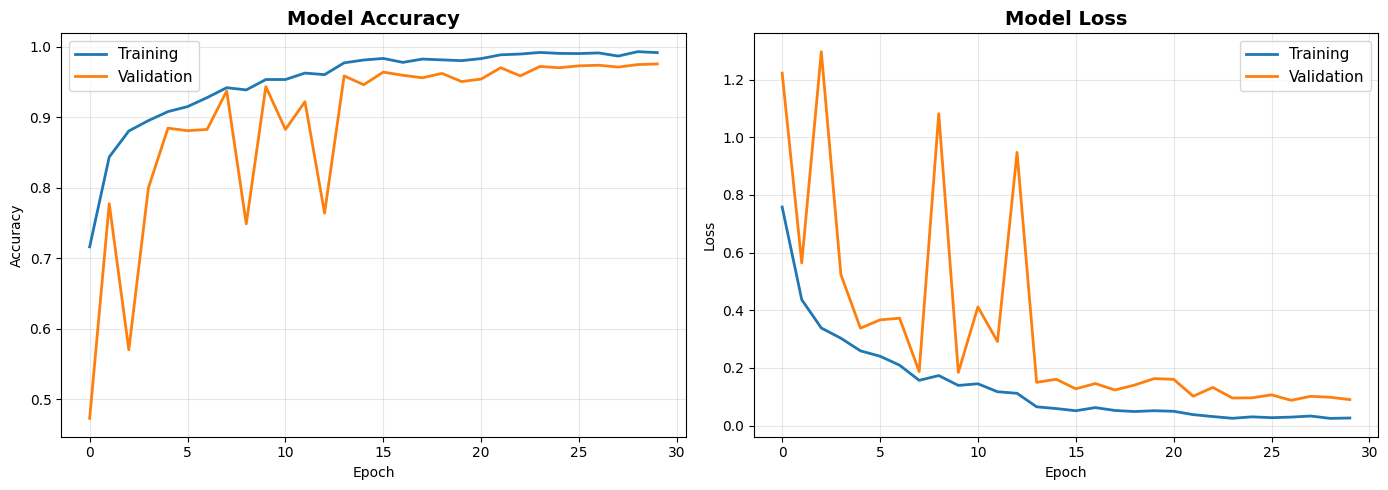

In [13]:
## Plot accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## Accuracy
axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

## Loss
axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### `8. Evaluate the Model`

In [18]:
## Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.9406 - loss: 0.4278

Test Loss: 0.4278
Test Accuracy: 0.9406 (94.06%)


### `9. Confusion Matrix & Classification Report`

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma     0.9939    0.8100    0.8926       400
  meningioma     0.9009    0.9550    0.9272       400
     notumor     0.9238    1.0000    0.9604       400
   pituitary     0.9568    0.9975    0.9767       400

    accuracy                         0.9406      1600
   macro avg     0.9439    0.9406    0.9392      1600
weighted avg     0.9439    0.9406    0.9392      1600



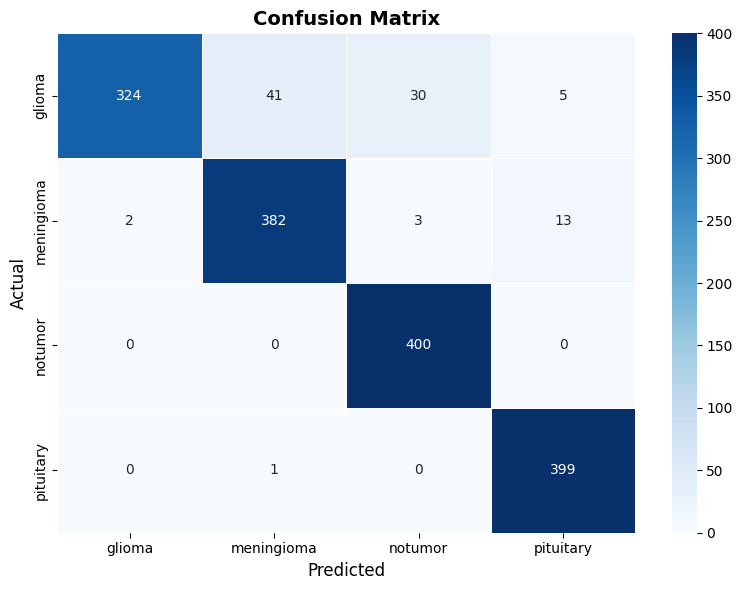

In [19]:
## Get predictions
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

## Classification Report
print('Classification Report:')
print('=' * 60)
print(classification_report(true_classes, predicted_classes, target_names=class_names, digits=4))

## Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax, linewidths=0.5)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

### `10. Save the Model`

In [55]:
import shutil

# Save model locally
os.makedirs('models', exist_ok=True)
model.save('models/brain_tumor_model.h5')
print('Model saved locally: models/brain_tumor_model.h5')

# Back up model to Google Drive (so it survives after Colab session ends)
if 'IN_COLAB' in globals() and IN_COLAB:
    drive_model_dir = '/content/drive/MyDrive/BrainTumorModels'
    os.makedirs(drive_model_dir, exist_ok=True)
    drive_model_path = os.path.join(drive_model_dir, 'brain_tumor_model.h5')
    shutil.copy('models/brain_tumor_model.h5', drive_model_path)
    print(f'Model backed up to Drive: {drive_model_path}')

print(f'Final Test Accuracy: {test_accuracy * 100:.2f}%')

Model saved locally: models/brain_tumor_model.h5
Model backed up to Drive: /content/drive/MyDrive/BrainTumorModels/brain_tumor_model.h5
Final Test Accuracy: 94.06%


### `11. Test with a Single Image`

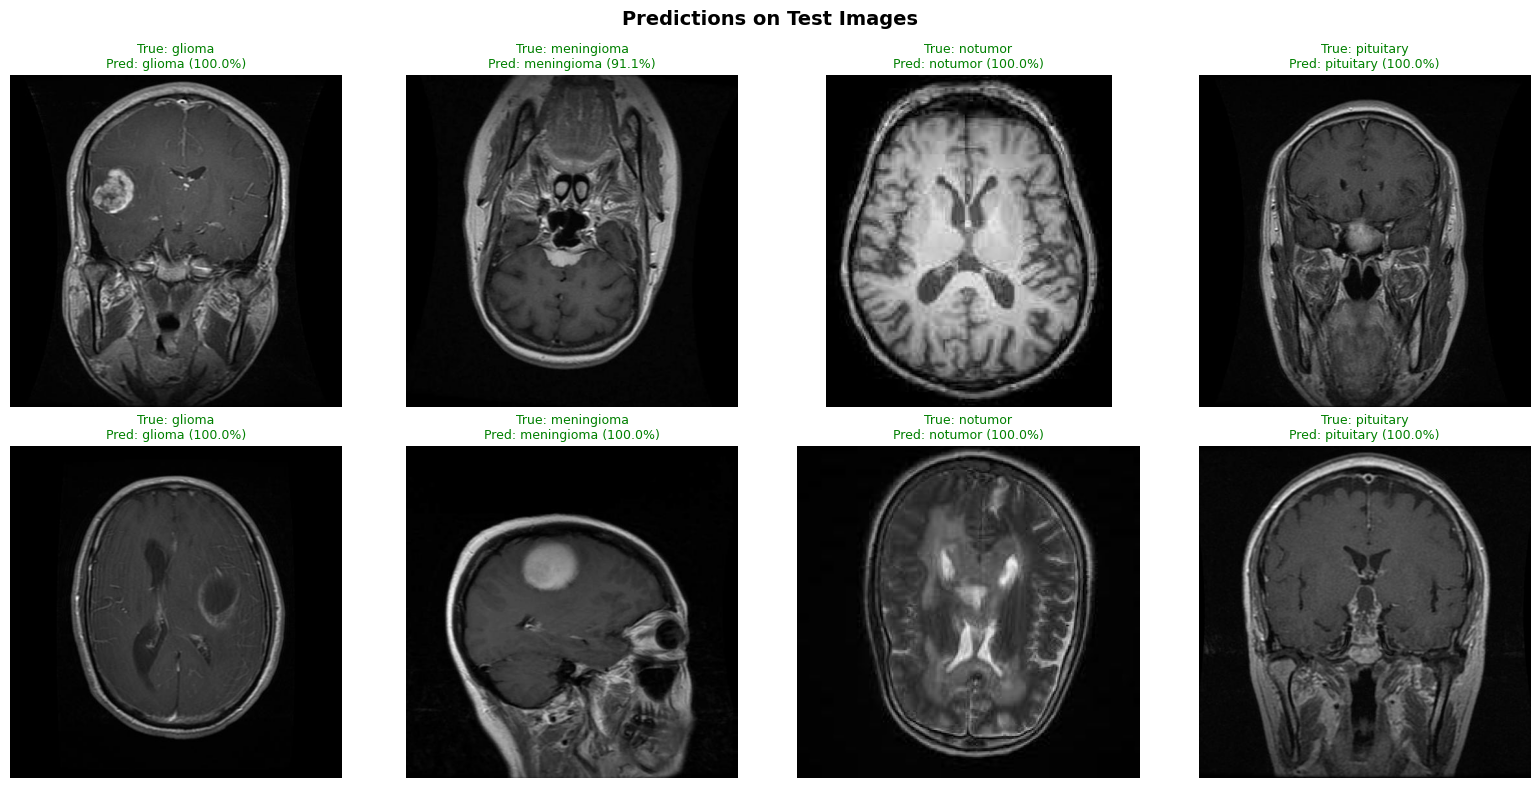

In [56]:
## Test prediction on a single image
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_single_image(img_path):
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array, verbose=0)
    pred_class = class_names[np.argmax(pred[0])]
    confidence = np.max(pred[0]) * 100
    return pred_class, confidence, pred[0]

## Test on random images from test set
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Predictions on Test Images', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    cls = class_names[i % len(class_names)]
    cls_dir = os.path.join(TEST_DIR, cls)
    img_name = os.listdir(cls_dir)[i]
    img_path = os.path.join(cls_dir, img_name)

    pred_class, confidence, _ = predict_single_image(img_path)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    color = 'green' if pred_class == cls else 'red'
    ax.set_title(f'True: {cls}\nPred: {pred_class} ({confidence:.1f}%)', fontsize=9, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()